## 1. Load Dataset and Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

X_train   = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_features.csv')
y_train   = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_target.csv')
X_val     = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_features.csv')
y_val     = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target.csv')
y_val_orig = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target_original.csv')
X_test    = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_features.csv')


## 1b. Encode categorical features

In [2]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col]   = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} labels -> 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns: {rest}")

print(f"\nLabelEncoded {len(object_cols)} cols | "
      f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


  date: 1700 labels -> 0..1699
  family: 33 labels -> 0..32
  type: 6 labels -> 0..5
  city: 23 labels -> 0..22
  state: 17 labels -> 0..16

LabelEncoded 5 cols | X_train (2974158, 48) | X_val (26730, 48) | X_test (28512, 48)


## 2. XGBoost Training

In [3]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    tree_method="hist",
    early_stopping_rounds=100,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)


[0]	validation_0-rmse:2.49164
[100]	validation_0-rmse:0.38842
[200]	validation_0-rmse:0.38413
[300]	validation_0-rmse:0.38281
[400]	validation_0-rmse:0.38108
[500]	validation_0-rmse:0.37969
[600]	validation_0-rmse:0.37860
[700]	validation_0-rmse:0.37764
[800]	validation_0-rmse:0.37705
[900]	validation_0-rmse:0.37681
[999]	validation_0-rmse:0.37635


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=100, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

## 3. Feature Importance

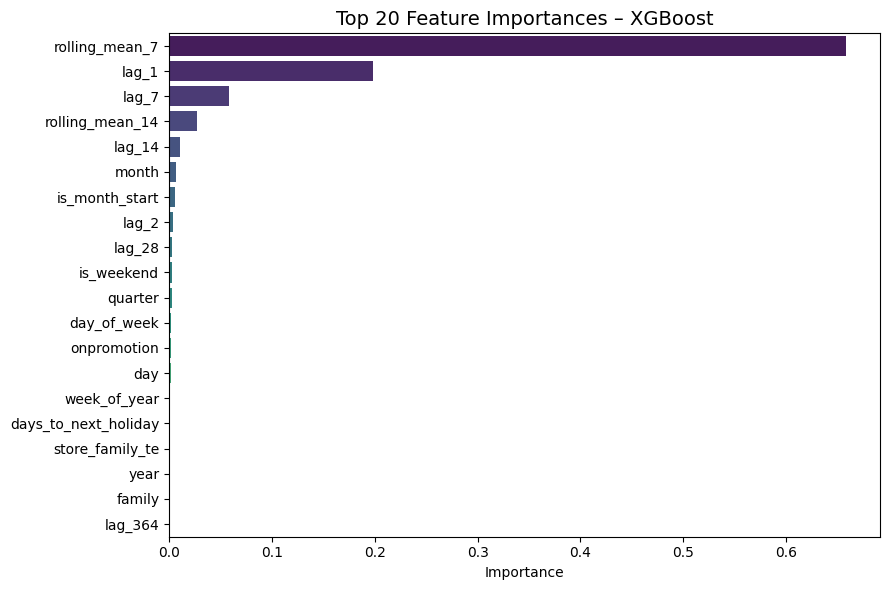


Top 20 features:
             feature  importance
      rolling_mean_7    0.658315
               lag_1    0.198400
               lag_7    0.057989
     rolling_mean_14    0.026888
              lag_14    0.010664
               month    0.006436
      is_month_start    0.005659
               lag_2    0.004064
              lag_28    0.002969
          is_weekend    0.002757
             quarter    0.002750
         day_of_week    0.002260
         onpromotion    0.001928
                 day    0.001698
        week_of_year    0.001344
days_to_next_holiday    0.001208
     store_family_te    0.001204
                year    0.001047
              family    0.000998
             lag_364    0.000973


In [4]:
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n  = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=top_df, x='importance', y='feature',
    hue='feature', palette='viridis', legend=False, ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances – XGBoost', fontsize=14)
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features:")
print(top_df.to_string(index=False))


## 4. Evaluation Metrics

In [5]:
def regression_metrics(y_true, y_pred):
    """y_true, y_pred: sales_log (log1p sales)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    sales_true = np.expm1(y_true)
    sales_pred = np.maximum(np.expm1(y_pred), 0.0)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle    = np.sqrt(mean_squared_log_error(sales_true, sales_pred))
    mae      = mean_absolute_error(sales_true, sales_pred)
    rmse     = np.sqrt(mean_squared_error(sales_true, sales_pred))
    eps      = 1e-8
    mape     = np.mean(np.abs((sales_true - sales_pred) / np.maximum(sales_true, eps))) * 100

    return {
        "RMSLE":              rmsle,
        "RMSE (sales units)": rmse,
        "MAE (sales units)":  mae,
        "MAPE (%)":           mape,
        "RMSE (log scale)":   rmse_log,
    }

y_val_arr    = y_val["sales_log"].values
y_pred_val   = model.predict(X_val)
metrics_val  = regression_metrics(y_val_arr, y_pred_val)

metrics_df = pd.DataFrame([metrics_val]).T
metrics_df.columns = ["validation"]
print("XGBoost — validation set:\n")
print(metrics_df.round(6).to_string())


XGBoost — validation set:

                      validation
RMSLE               3.763350e-01
RMSE (sales units)  2.124156e+02
MAE (sales units)   6.220569e+01
MAPE (%)            5.351202e+08
RMSE (log scale)    3.763460e-01


## 5. Error Analysis

In [6]:
# ── Build val_df: central dataframe for all error analysis ──
y_pred_val      = model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)
y_actual        = (y_val_orig["sales"].values
                   if isinstance(y_val_orig, pd.DataFrame)
                   else y_val_orig.values)

date_val = pd.to_datetime(X_val[["year", "month", "day"]])

val_df = pd.DataFrame({
    "date"      : date_val.values,
    "store_nbr" : X_val["store_nbr"].values,
    "family"    : X_val["family"].values,
    "actual"    : y_actual,
    "predicted" : val_pred_actual,
})
val_df["residual"] = val_df["actual"] - val_df["predicted"]


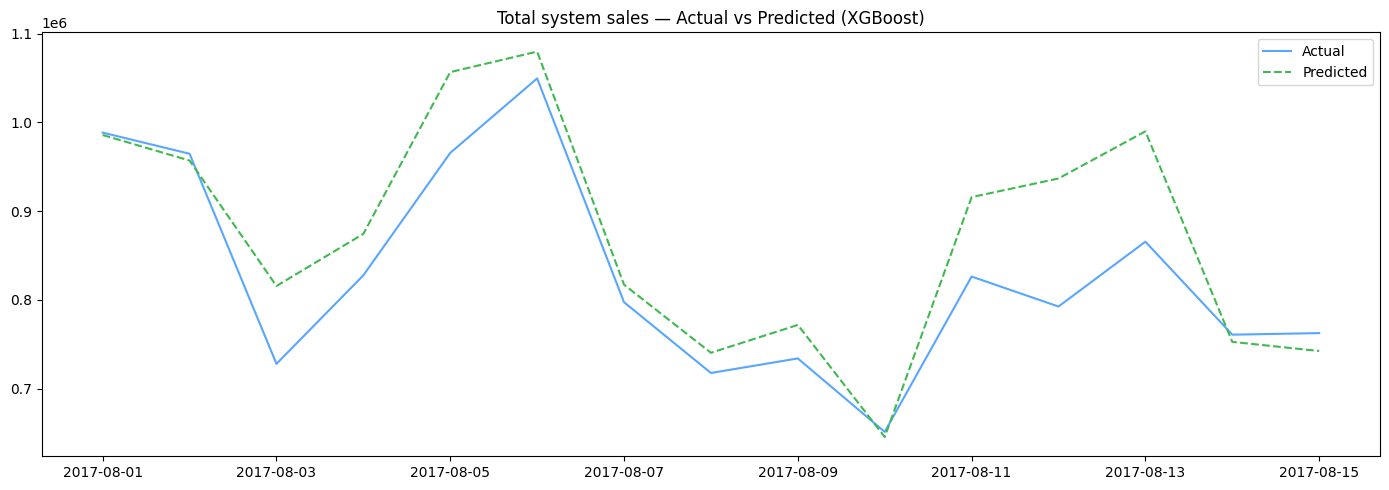

In [7]:
daily = (
    val_df[["date", "actual", "predicted"]]
    .groupby("date").sum()
)

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily.index, daily["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total system sales — Actual vs Predicted (XGBoost)")
plt.legend()
plt.tight_layout()
plt.show()


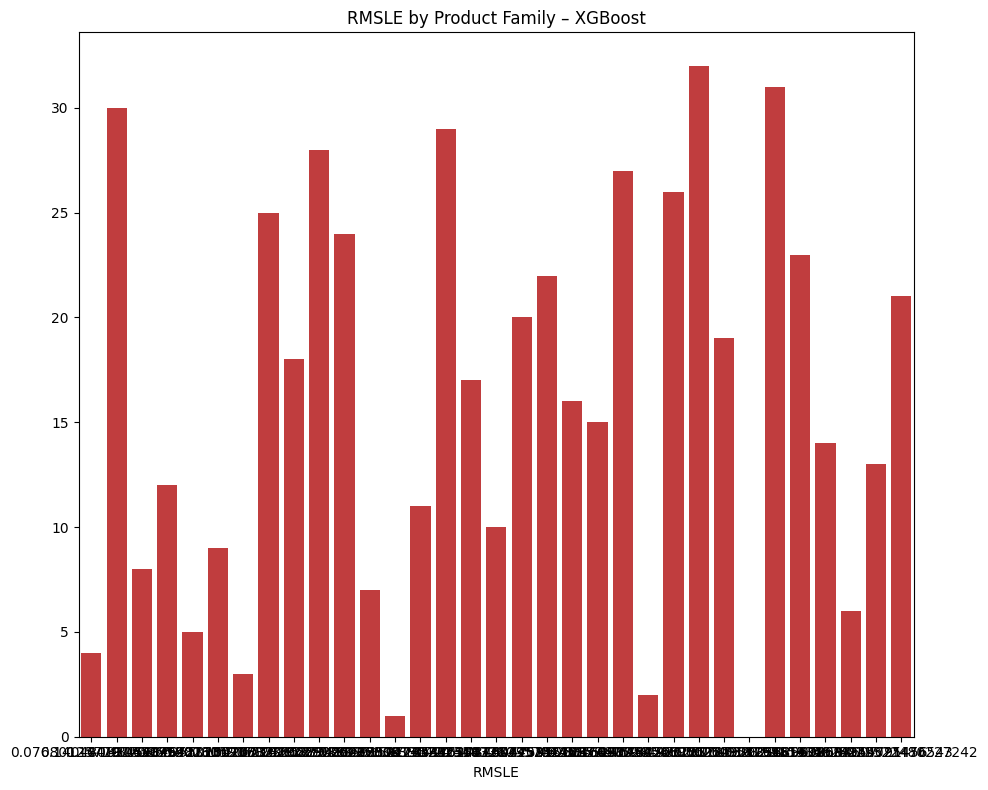

Top 5 families with highest RMSLE:
 family    rmsle
     21 0.601132
     13 0.562823
      6 0.531497
     14 0.531193
     23 0.511646


In [8]:
# ── RMSLE by product family ──
family_results = []
for family in val_df["family"].unique():
    mask = val_df["family"] == family
    sub  = val_df[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    family_results.append({"family": family, "rmsle": r})

df_family = pd.DataFrame(family_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_family, x="rmsle", y="family", color="#d62728", ax=ax)
ax.set_title("RMSLE by Product Family – XGBoost")
ax.set_xlabel("RMSLE"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Top 5 families with highest RMSLE:")
print(df_family.head(5).to_string(index=False))


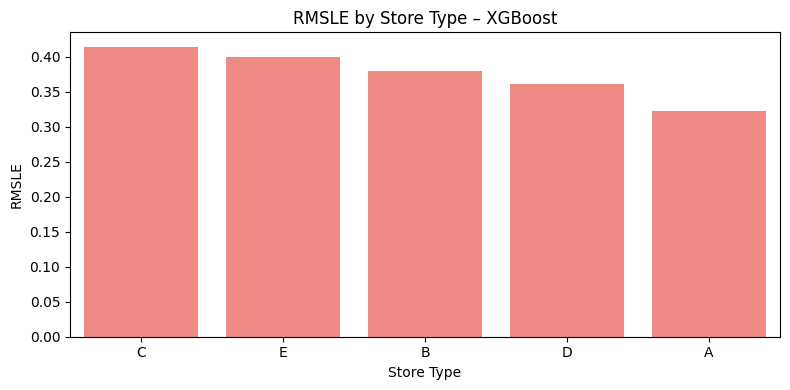

In [9]:
# ── RMSLE by store type ──
stores = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\stores_cleaned.csv')
val_store = val_df.merge(stores[["store_nbr", "type"]], on="store_nbr", how="left")

store_results = []
for stype in val_store["type"].unique():
    mask = val_store["type"] == stype
    sub  = val_store[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    store_results.append({"store_type": stype, "rmsle": r})

df_store = pd.DataFrame(store_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_store, x="store_type", y="rmsle", color="#ff7b72", ax=ax)
ax.set_title("RMSLE by Store Type – XGBoost")
ax.set_xlabel("Store Type"); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()


Holiday: RMSLE = 0.3711 (7,128 rows)
Non-Holiday: RMSLE = 0.3782 (19,602 rows)


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_24072\462219107.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)


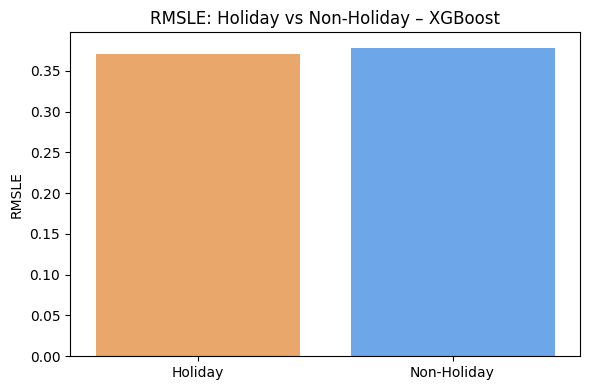

In [10]:
# ── Holiday vs Non-Holiday ──
holidays = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\holidays_events_cleaned.csv')
holiday_dates        = set(pd.to_datetime(holidays["date"]).dt.strftime("%Y-%m-%d"))
val_df["date_str"]   = pd.to_datetime(val_df["date"]).dt.strftime("%Y-%m-%d")
val_df["is_holiday"] = val_df["date_str"].isin(holiday_dates)

holiday_summary = []
for label, mask in [("Holiday", val_df["is_holiday"]), ("Non-Holiday", ~val_df["is_holiday"])]:
    sub = val_df[mask]
    r   = np.sqrt(mean_squared_log_error(sub["actual"].clip(0), sub["predicted"].clip(0)))
    holiday_summary.append({"label": label, "rmsle": r, "n_rows": int(mask.sum())})
    print(f"{label}: RMSLE = {r:.4f} ({int(mask.sum()):,} rows)")

fig, ax = plt.subplots(figsize=(6, 4))
df_hol = pd.DataFrame(holiday_summary)
sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)
ax.set_title("RMSLE: Holiday vs Non-Holiday – XGBoost")
ax.set_xlabel(""); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()


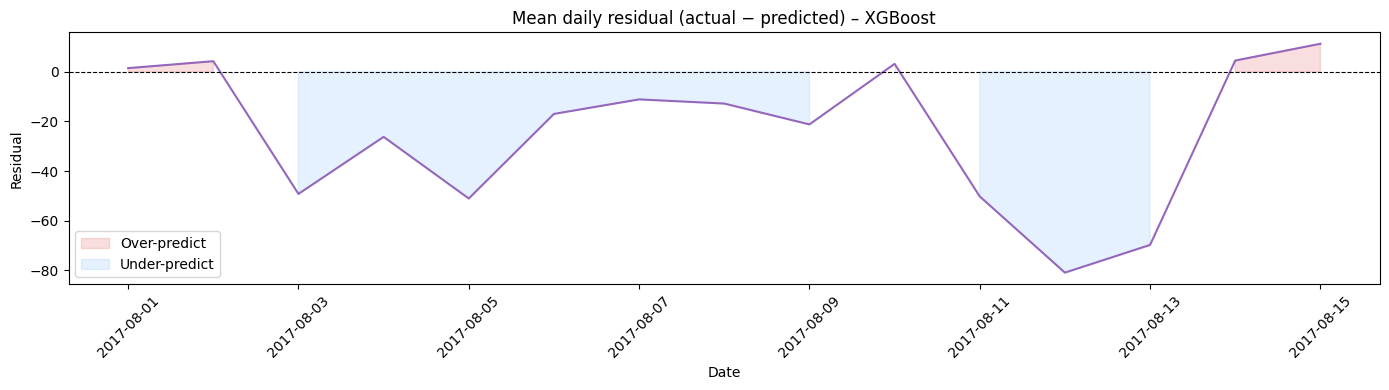

In [11]:
# ── Daily mean residual ──
daily_resid = val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Over-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Under-predict")
ax.set_title("Mean daily residual (actual − predicted) – XGBoost")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()


In [12]:
# ── Summary ──
print("\n" + "="*45)
print("ERROR ANALYSIS SUMMARY — XGBoost")
print("="*45)
print(f"Mean residual  : {val_df['residual'].mean():+.4f}  (+ = under, - = over)")
print(f"Std  residual  : {val_df['residual'].std():.4f}")
print(f"Worst family   : {df_family.iloc[0]['family']} (RMSLE={df_family.iloc[0]['rmsle']:.4f})")
print(f"Best  family   : {df_family.iloc[-1]['family']} (RMSLE={df_family.iloc[-1]['rmsle']:.4f})")
print(f"Worst store type: {df_store.iloc[0]['store_type']} (RMSLE={df_store.iloc[0]['rmsle']:.4f})")
print("="*45)



ERROR ANALYSIS SUMMARY — XGBoost
Mean residual  : -24.2979  (+ = under, - = over)
Std  residual  : 211.0253
Worst family   : 21.0 (RMSLE=0.6011)
Best  family   : 4.0 (RMSLE=0.0768)
Worst store type: C (RMSLE=0.4144)
